In [1]:
# Customer Segmentation and Recommendation System for an Online Retail Business

In [2]:
# DSM Step 1: <Problem Identification Statement>

# Considering an online retail store, how can we segment customers into different groups and then recommend products based on a historical transaction dataset?

# Context:
# To expand business, an online retailing company wants to have a comprehensive analysis of the customers and products.
# Therefore, the company wants to segment customers based on shopping behavior and then recommend them most related products.

# Criteria for Success:
# Divide customers into optimal segments and offer most related products using machine learning techniques.

#Scope of Solution Space:
# Using machine learning techniques, and based on a historical transaction database, we want to group customers based on shopping trends.
# After customer segmentation, we need to find most related products for each segment.
# As the result of this segmentation, customers will be receiving related promotions and advertisements.
# A comprehensive data analysis with data visualization will be sent to stakeholders as the final report.

# Constraints:
# 1) Data source includes transactions for only two years, 2010 and 2011.
# 2) The currency is not mentioned, but I assume it is in US Dollars.

# Stakeholders:
# The online retail company marketing team, executive sales manager, and the IT Development team are stakeholders for this project.

# Data Sources:
# The data is captured from Kaggle.com , but the original source is UCI Machine Learning Repository.
# The dataset is in the format of an Excel file and includes transactions for the year 2010 and 2011. Here is a link to access this data source:
# https://www.kaggle.com/code/farzadnekouei/customer-segmentation-recommendation-system

In [98]:
# Importing packages and libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt
import scipy.stats as stats
import matplotlib.dates as mdates
from scipy import stats
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture

In [4]:
# Loading the dataset:

# The data source for this project is an Excel file.

retail_df = pd.read_csv('/content/data_online_retail.csv', encoding='latin1')

In [5]:
# DSM Step 2: <Data Wrangling>

# After loading the dataset, importing packages and libraries, it is time to clean the data.

# Let's check first five rows of the dataset:

retail_df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [6]:
retail_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [7]:
retail_df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [8]:
retail_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Quantity,541909.0,9.552250,218.081158,-80995.00,1.00,3.00,10.00,80995.0
UnitPrice,541909.0,4.611114,96.759853,-11062.06,1.25,2.08,4.13,38970.0
CustomerID,406829.0,15287.690570,1713.600303,12346.00,13953.00,15152.00,16791.00,18287.0


In [9]:
retail_df.shape

(541909, 8)

In [10]:
# Let's see how many NULL values we have in every columns:

retail_df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


In [11]:
# Let's drop Null values from customer_id and Description, since both of those are small portions of dataframe.

retail_df = retail_df.dropna(subset=['CustomerID'])
retail_df = retail_df.dropna(subset=['Description'])

retail_df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,0
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,0
Country,0


In [12]:
retail_df.shape

(406829, 8)

In [13]:
# Let's chaeck data types:

retail_df.dtypes

,0
InvoiceNo,object
StockCode,object
Description,object
Quantity,int64
InvoiceDate,object
UnitPrice,float64
CustomerID,float64
Country,object


In [14]:
# These data types need to be changed:

# InvoiceDate >>> from string to datetime
# InvoiceNo >>> from string to float64
# Quantity >>> from float to integer

# However, InvoiceNo cannot be converted to float because it includes alphabet letters. So we keep it as string.

retail_df['InvoiceDate'] = pd.to_datetime(retail_df['InvoiceDate'])

retail_df['Quantity'] = retail_df['Quantity'].astype('int64')

retail_df.dtypes

,0
InvoiceNo,object
StockCode,object
Description,object
Quantity,int64
InvoiceDate,datetime64[ns]
UnitPrice,float64
CustomerID,float64
Country,object


In [15]:
# Everything else looks good to me.
# We do not have any Null values.
# All data types are correct.
# All columns have appropriate name.


# Let's print head and tail of retail_df and see if we can find something to explore.

retail_df.head()


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [16]:
retail_df.tail()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France
541908,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France


In [17]:
# Lets' find max and min price:

print(f"Cheapest item is {retail_df['UnitPrice'].min()}")

print(f"Most expensive item is {retail_df['UnitPrice'].max()}")

Cheapest item is 0.0
Most expensive item is 38970.0


In [18]:
# The cheapest item is 0$ which means the data was not captured. I keep those rows since we still can extract useful information.

In [19]:
# Let's find mosgt ordered and least ordered items:

print(f"Most ordered item is {retail_df['Quantity'].max()}")
print(f"Least ordered item is {retail_df['Quantity'].min()}")

Most ordered item is 80995
Least ordered item is -80995


In [20]:
# Weird! We have negative quantity. Let's explore the Quantity:

retail_df['Quantity'].unique()

array([     6,      8,      2,     32,      3,      4,     24,     12,
           48,     18,     20,     36,     80,     64,     10,    120,
           96,     23,      5,      1,     -1,     50,     40,    100,
          192,    432,    144,    288,    -12,    -24,     16,      9,
          128,     25,     30,     28,      7,     72,    200,    600,
          480,     -6,     14,     -2,     -4,     -5,     -7,     -3,
           11,     70,    252,     60,    216,    384,     27,    108,
           52,  -9360,     75,    270,     42,    240,     90,    320,
           17,   1824,    204,     69,    -36,   -192,   -144,    160,
         2880,   1400,     19,     39,    -48,    -50,     56,     13,
         1440,     -8,     15,    720,    -20,    156,    324,     41,
          -10,    -72,    -11,    402,    378,    150,    300,     22,
           34,    408,    972,    208,   1008,     26,   1000,    -25,
         1488,    250,   1394,    400,    110,    -14,     37,    -33,
      

In [21]:
# Negative quantity is misleading. Let's change them to zero.

retail_df['Quantity'] = retail_df['Quantity'].where(retail_df['Quantity'] >= 0, 0)

retail_df['Quantity'].unique()

array([    6,     8,     2,    32,     3,     4,    24,    12,    48,
          18,    20,    36,    80,    64,    10,   120,    96,    23,
           5,     1,     0,    50,    40,   100,   192,   432,   144,
         288,    16,     9,   128,    25,    30,    28,     7,    72,
         200,   600,   480,    14,    11,    70,   252,    60,   216,
         384,    27,   108,    52,    75,   270,    42,   240,    90,
         320,    17,  1824,   204,    69,   160,  2880,  1400,    19,
          39,    56,    13,  1440,    15,   720,   156,   324,    41,
         402,   378,   150,   300,    22,    34,   408,   972,   208,
        1008,    26,  1000,  1488,   250,  1394,   400,   110,    37,
          78,    21,   272,    84,    47,  1728,    38,    53,    76,
         576,    29,  2400,   500,   180,   960,  1296,   147,   168,
         256,    54,    31,   860,  1010,  1356,  1284,   186,   114,
         360,  1930,  2000,  3114,  1300,   670,   176,   648,    62,
       74215,    89,

In [22]:
# As the last step, let's see which customer purchased more items:

retail_df['CustomerID'].value_counts()


,count
CustomerID,
17841.0,7983
14911.0,5903
14096.0,5128
12748.0,4642
14606.0,2782
...,...
17986.0,1
13256.0,1
18184.0,1


In [23]:
# I would like to use describe() method again to see if I can find outliers at this stage:

retail_df.describe().T

,count,mean,min,25%,50%,75%,max,std
Quantity,406829.0,12.736791,0.0,2.0,5.0,12.0,80995.0,178.444861
InvoiceDate,406829,2011-07-10 16:30:57.879207424,2010-12-01 08:26:00,2011-04-06 15:02:00,2011-07-31 11:48:00,2011-10-20 13:06:00,2011-12-09 12:50:00,NaN
UnitPrice,406829.0,3.460471,0.0,1.25,1.95,3.75,38970.0,69.315162
CustomerID,406829.0,15287.69057,12346.0,13953.0,15152.0,16791.0,18287.0,1713.600303


In [24]:
# Max number of Quantity is 74215, which means a customer has that many order. Let's dive deeper on this:

retail_df['Quantity'].sort_values(ascending=False).head(10)

,Quantity
540421,80995
61619,74215
502122,12540
421632,4800
206121,4300
97432,3906
270885,3186
160546,3114
52711,3114
433788,3000


In [27]:
retail_df = retail_df[~retail_df['Quantity'].isin([74215, 80995, 12540])]

In [28]:
# Let's do the exact same process to see if we find any outliers in UnitPrice column:

retail_df['UnitPrice'].sort_values(ascending=False).head(10)

,UnitPrice
222681,38970.00
173382,8142.75
173277,8142.75
173391,6930.00
268027,4287.63
422375,4161.06
422376,4161.06
422351,4161.06
406406,3949.32
406404,3949.32


In [29]:
# And also sort prices from low to high:

retail_df['UnitPrice'].sort_values().head(10)


,UnitPrice
436428,0.0
436597,0.0
436961,0.0
139453,0.0
40089,0.0
130188,0.0
145208,0.0
33576,0.0
454464,0.0
395529,0.0


In [30]:
# We cannopt rely on UnitPrice average, because we have so many values close to zero which looks not correct.
# I do not remove these values, but I make sure to not involve average price value in my analysis.

# There are also two UnitPrice values which are much higher than others.
# Hard to say if those are bad data becasue an online store may have expensive items as well.
# Howeve, if those super expensive items are ordered only one time, we can remove them since they do not easily go under any segment.

In [31]:
retail_df['UnitPrice'][retail_df['UnitPrice'] > 500].count()

np.int64(86)

In [32]:
# Only two ordered items are that much expensive.
# I remove those two values because this online retail should not sell items with those prices.

retail_df = retail_df[retail_df['UnitPrice'] <= 500]

In [33]:
# We should see some change in mean value if I call describe() again:

retail_df.describe().T

,count,mean,min,25%,50%,75%,max,std
Quantity,406740.0,12.326907,0.0,2.0,5.0,12.0,4800.0,42.461154
InvoiceDate,406740,2011-07-10 16:26:20.201947136,2010-12-01 08:26:00,2011-04-06 14:53:00,2011-07-31 11:48:00,2011-10-20 13:06:00,2011-12-09 12:50:00,NaN
UnitPrice,406740.0,3.027045,0.0,1.25,1.95,3.75,495.98,6.033515
CustomerID,406740.0,15287.918429,12346.0,13954.0,15152.0,16791.0,18287.0,1713.534402


In [34]:
# Let's count unique number of CustomerID:

retail_df['CustomerID'].nunique()

4366

In [35]:
# And unique number of InvoiceNo:

retail_df['InvoiceNo'].nunique()

22121

In [36]:
# I saw some of InvoiceNo has alphabetic letter C, which is a wrong format for this dataset.
# I need to remove those Invoices, so then I can canvert data type from string to integer:

retail_df = retail_df[~retail_df['InvoiceNo'].str.contains('C')]

In [38]:
# Now, let's check data type first, and then convert InvoiceNo from string to integer:

retail_df.dtypes

,0
InvoiceNo,object
StockCode,object
Description,object
Quantity,int64
InvoiceDate,datetime64[ns]
UnitPrice,float64
CustomerID,float64
Country,object


In [39]:
# Convert InvoiceNo from string to integer:

retail_df['InvoiceNo'].astype('int64')

,InvoiceNo
0,536365
1,536365
2,536365
3,536365
4,536365
...,...
541904,581587
541905,581587
541906,581587
541907,581587


In [42]:
# We are done with data cleaning. The data looks clean now.
# Let's save the result to new Excel file and keep it for future work.

retail_df.to_csv('cleansed_data.csv', index=False)


In [43]:
# DSM Step 3: <EDA__Exploratory Data Analysis>

In [45]:
# Load the cleansed dataset from previous notebook and call it dfc:

dfc = pd.read_csv('/content/cleansed_data.csv')

In [46]:
dfc.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [47]:
# Check data types since importing an Excel file may breake previous data types:

dfc.dtypes

,0
InvoiceNo,int64
StockCode,object
Description,object
Quantity,int64
InvoiceDate,object
UnitPrice,float64
CustomerID,float64
Country,object


In [48]:
# InvoiceDate needs to be converted to datetime again:

dfc['InvoiceDate'] = pd.to_datetime(dfc['InvoiceDate'])
dfc.dtypes

,0
InvoiceNo,int64
StockCode,object
Description,object
Quantity,int64
InvoiceDate,datetime64[ns]
UnitPrice,float64
CustomerID,float64
Country,object


In [49]:
# I am going to delete Country column since all transactions happened in United Kingdom.

dfc = dfc.drop('Country', axis=1)

In [50]:
dfc.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0


In [51]:
# Now, I am going to draw some plots to explore the data.

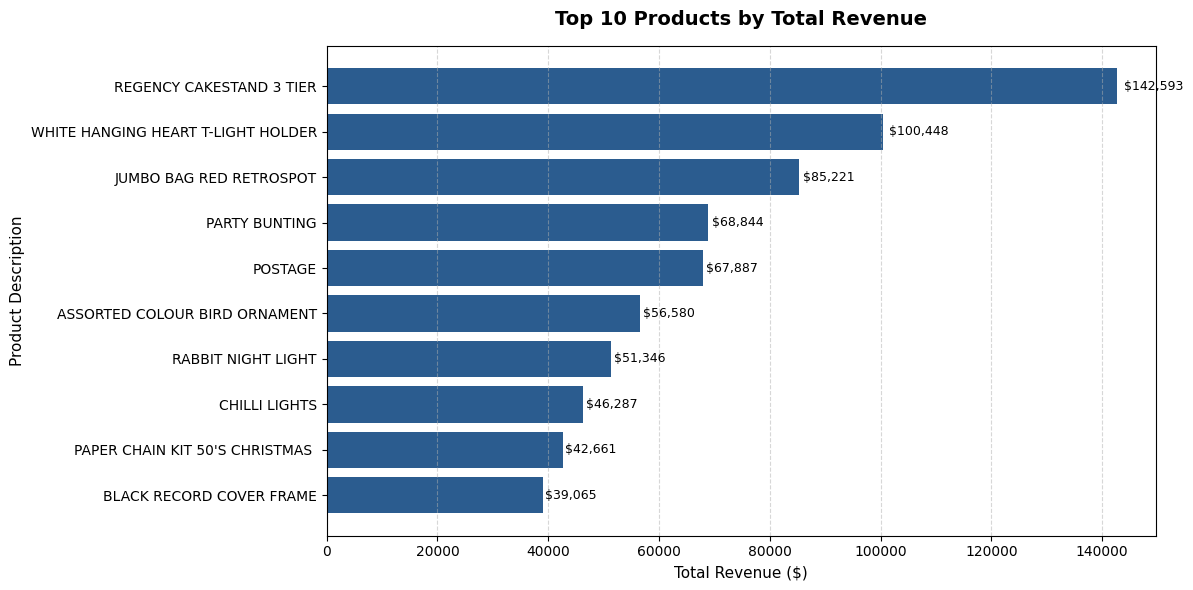

In [52]:
# 1. Create the Revenue column
dfc['Revenue'] = dfc['Quantity'] * dfc['UnitPrice']

# 2. Filter out returns/cancellations (negative values) and missing descriptions
dfc_valid = dfc[(dfc['Quantity'] > 0) & (dfc['UnitPrice'] > 0)].dropna(
    subset=['Description']
)

# 3. Calculate total revenue per product and take top 10
top10_revenue = (
    dfc_valid.groupby('Description')['Revenue']
    .sum()
    .nlargest(10)
    .sort_values(ascending=True)  # Sort ascending so largest bar is at the top
)

# 4. Create the Matplotlib plot
plt.figure(figsize=(12, 6))

# Plot horizontal bar chart
bars = plt.barh(top10_revenue.index, top10_revenue.values, color='#2b5c8f')

# Add data labels at the end of each bar
for bar in bars:
    width = bar.get_width()
    plt.text(
        width * 1.01,
        bar.get_y() + bar.get_height() / 2,
        f'${width:,.0f}',
        va='center',
        ha='left',
        fontsize=9,
    )

# Formatting
plt.title('Top 10 Products by Total Revenue', fontsize=14, pad=15, weight='bold')
plt.xlabel('Total Revenue ($)', fontsize=11)
plt.ylabel('Product Description', fontsize=11)
plt.grid(axis='x', linestyle='--', alpha=0.5)

# Adjust layout to prevent clipping long product names
plt.tight_layout()
plt.show()

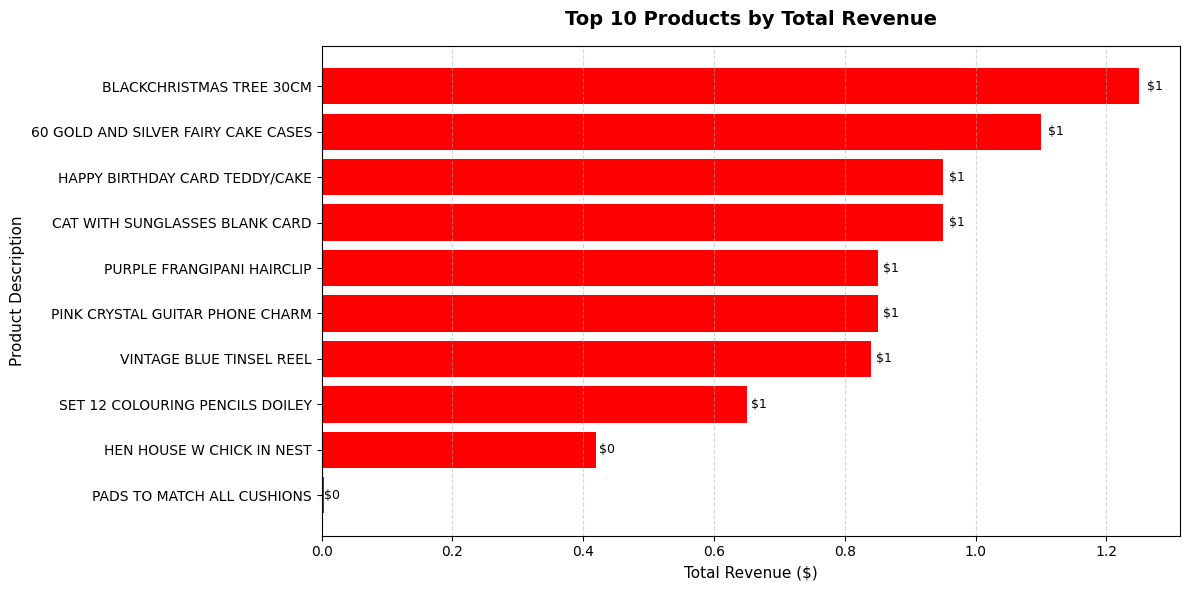

In [53]:
# Now let's see revenue for lowest 10 products:

# 1. Create the Revenue column
dfc['Revenue'] = dfc['Quantity'] * dfc['UnitPrice']

# 2. Filter out returns/cancellations (negative values) and missing descriptions
dfc_valid = dfc[(dfc['Quantity'] > 0) & (dfc['UnitPrice'] > 0)].dropna(
    subset=['Description']
)

# 3. Calculate total revenue per product and take top 10
top10_revenue = (
    dfc_valid.groupby('Description')['Revenue']
    .sum()
    .nsmallest(10)
    .sort_values(ascending=True)  # Sort ascending so largest bar is at the top
)

# 4. Create the Matplotlib plot
plt.figure(figsize=(12, 6))

# Plot horizontal bar chart
bars = plt.barh(top10_revenue.index, top10_revenue.values, color='red')

# Add data labels at the end of each bar
for bar in bars:
    width = bar.get_width()
    plt.text(
        width * 1.01,
        bar.get_y() + bar.get_height() / 2,
        f'${width:,.0f}',
        va='center',
        ha='left',
        fontsize=9,
    )

# Formatting
plt.title('Top 10 Products by Total Revenue', fontsize=14, pad=15, weight='bold')
plt.xlabel('Total Revenue ($)', fontsize=11)
plt.ylabel('Product Description', fontsize=11)
plt.grid(axis='x', linestyle='--', alpha=0.5)

# Adjust layout to prevent clipping long product names
plt.tight_layout()
plt.show()

In [54]:
# The red bar chart shows us so many values are recorded without a valid price, or with no price.
# As I mentioned in Data Wrangling step, I keep these rows since other useful information may be extracted.

# Now let's draw customer purchase frequency distribution.
# Instead of dfc_valid, I have used dfc1_valid to not affect other cells.

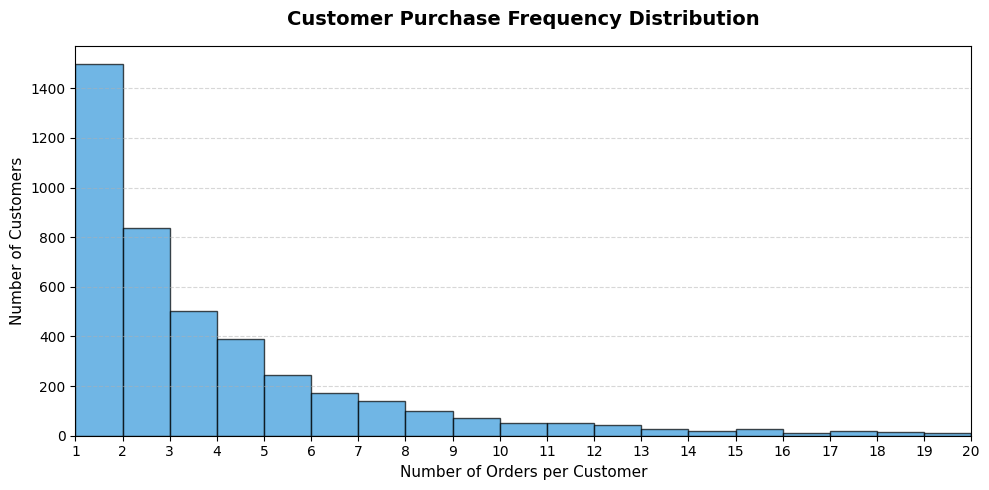

In [55]:
# 1. Filter out missing CustomerIDs and cancelled transactions
dfc1_valid = dfc[(dfc['Quantity'] > 0) & (dfc['CustomerID'].notna())]

# 2. Count unique orders (InvoiceNo) per customer
customer_freq = dfc1_valid.groupby('CustomerID')['InvoiceNo'].nunique()

# 3. Create the Matplotlib Histogram
plt.figure(figsize=(10, 5))

# Plot histogram (bins set up to capture distinct integer order counts)
plt.hist(
    customer_freq,
    bins=range(1, customer_freq.max() + 2),
    color='#3498db',
    edgecolor='black',
    alpha=0.7,
)

# Set x-axis limit to focus on the majority of customers (e.g., up to 20 orders)
plt.xlim(1, 20)
plt.xticks(range(1, 21))

# Labels and Formatting
plt.title(
    'Customer Purchase Frequency Distribution',
    fontsize=14,
    pad=15,
    weight='bold',
)
plt.xlabel('Number of Orders per Customer', fontsize=11)
plt.ylabel('Number of Customers', fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

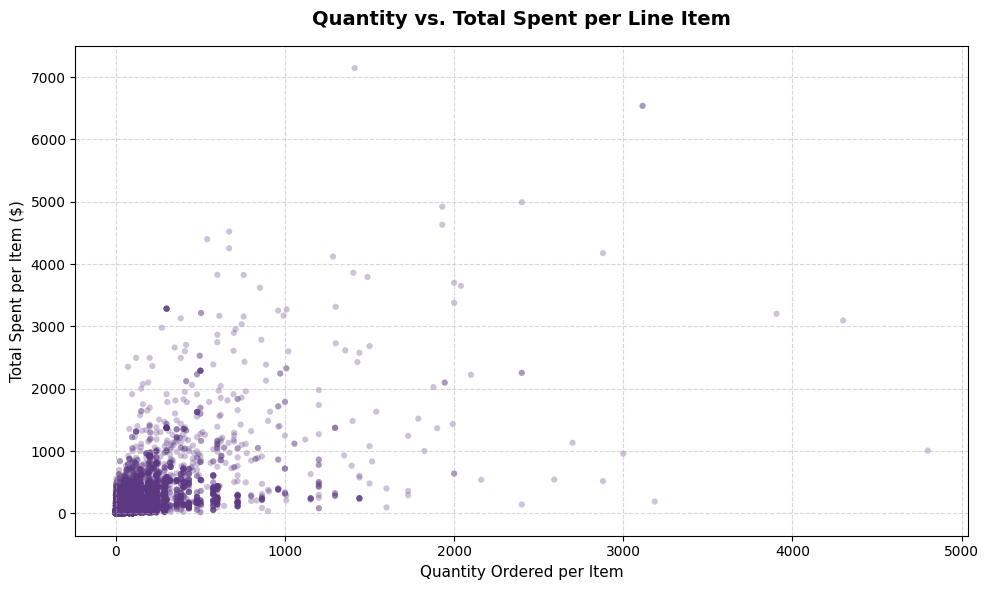

In [56]:
# Next plot is a scatterplot of Quantity vs revenue:

# 1. Calculate Total Spent (Revenue per line item)
dfc['TotalSpent'] = dfc['Quantity'] * dfc['UnitPrice']

# 2. Filter out returns and bad data for cleaner visualization
df_clean = dfc[(dfc['Quantity'] > 0) & (dfc['UnitPrice'] > 0)]

# 3. Create the Scatter Plot
plt.figure(figsize=(10, 6))

plt.scatter(
    df_clean['Quantity'],
    df_clean['TotalSpent'],
    alpha=0.3,  # Transparency helps show point density where thousands overlap
    color='#5c3882',
    edgecolors='none',
    s=20,  # Smaller marker size for crowded datasets
)

# Formatting
plt.title(
    'Quantity vs. Total Spent per Line Item',
    fontsize=14,
    pad=15,
    weight='bold',
)
plt.xlabel('Quantity Ordered per Item', fontsize=11)
plt.ylabel('Total Spent per Item ($)', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

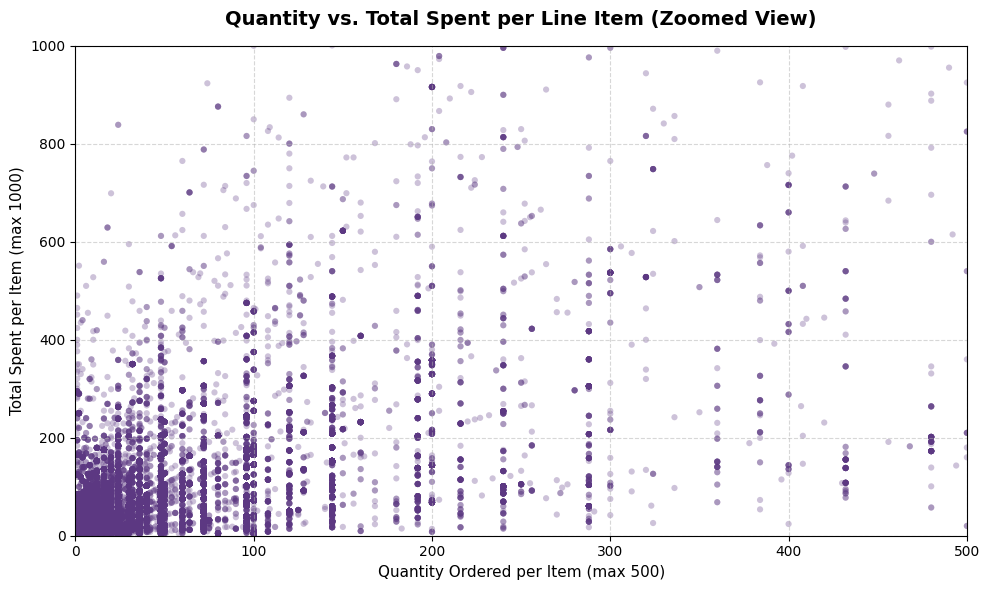

In [57]:
# As it can be seen from the scatterplot, majority of data is focused on bottom left corner. We have so many outliers too.
# For a better and more accurate conclusion, let's limit order quantity to 500 and revenue to 1000$.

# 1. Calculate Total Spent
dfc['TotalSpent'] = dfc['Quantity'] * dfc['UnitPrice']

# 2. Filter out returns / non-positive data
df_clean = dfc[(dfc['Quantity'] > 0) & (dfc['UnitPrice'] > 0)]

# 3. Create Scatter Plot
plt.figure(figsize=(10, 6))

plt.scatter(
    df_clean['Quantity'],
    df_clean['TotalSpent'],
    alpha=0.3,
    color='#5c3882',
    edgecolors='none',
    s=20,
)

# --- ZOOM AXES ---
plt.xlim(0, 500)
plt.ylim(0, 1000)

# Formatting
plt.title(
    'Quantity vs. Total Spent per Line Item (Zoomed View)',
    fontsize=14,
    pad=15,
    weight='bold',
)
plt.xlabel('Quantity Ordered per Item (max 500)', fontsize=11)
plt.ylabel('Total Spent per Item (max 1000)', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

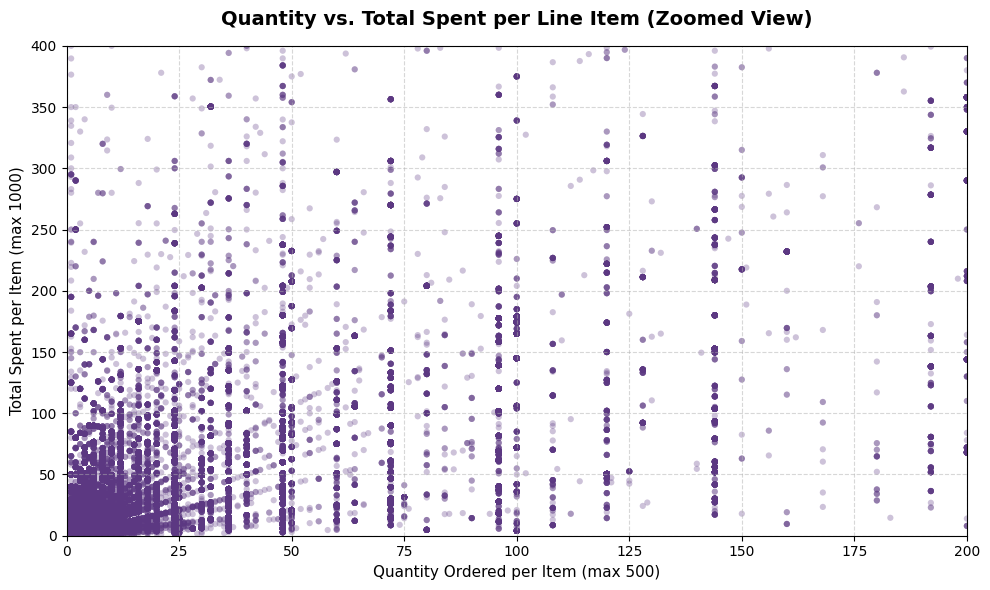

In [58]:
# Let's zoom even more to quantity=200 and revenue 400

# 1. Calculate Total Spent
dfc['TotalSpent'] = dfc['Quantity'] * dfc['UnitPrice']

# 2. Filter out returns / non-positive data
df_clean = dfc[(dfc['Quantity'] > 0) & (dfc['UnitPrice'] > 0)]

# 3. Create Scatter Plot
plt.figure(figsize=(10, 6))

plt.scatter(
    df_clean['Quantity'],
    df_clean['TotalSpent'],
    alpha=0.3,
    color='#5c3882',
    edgecolors='none',
    s=20,
)

# --- ZOOM AXES ---
plt.xlim(0, 200)
plt.ylim(0, 400)

# Formatting
plt.title(
    'Quantity vs. Total Spent per Line Item (Zoomed View)',
    fontsize=14,
    pad=15,
    weight='bold',
)
plt.xlabel('Quantity Ordered per Item (max 500)', fontsize=11)
plt.ylabel('Total Spent per Item (max 1000)', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

Dataset start date: 2010-12-01 08:26:00
Dataset end date:   2011-12-09 12:50:00
Total date span:    373 days


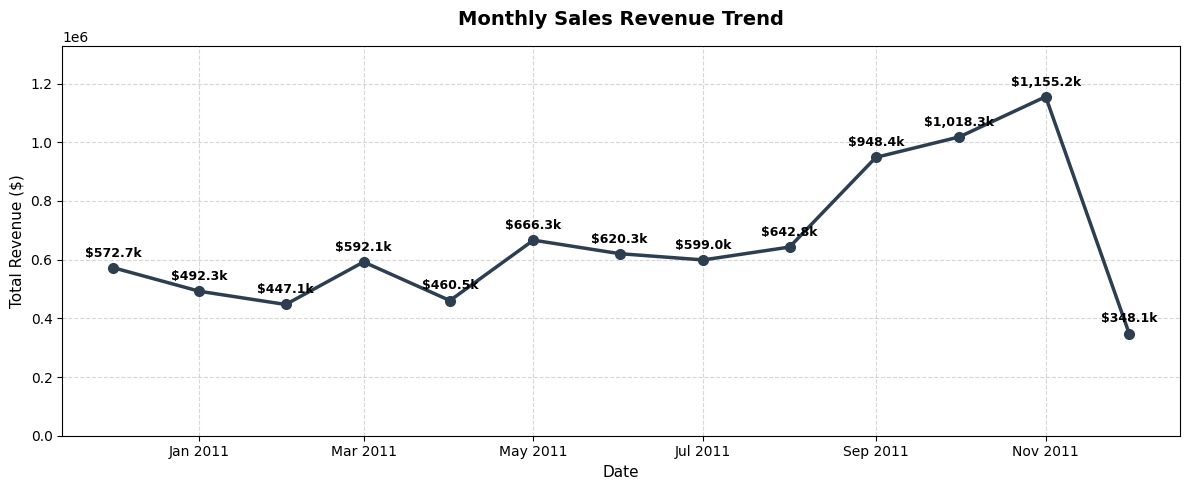

In [59]:
# 1. Force robust datetime conversion (handles strings, timestamps, etc.)
dfc['InvoiceDate'] = pd.to_datetime(dfc['InvoiceDate'], errors='coerce')

# Drop rows with invalid dates or missing values
df = dfc.dropna(subset=['InvoiceDate'])

# 2. Calculate Total Revenue per row
dfc['TotalSpent'] = dfc['Quantity'] * dfc['UnitPrice']

# Filter valid transactions
df_clean = dfc[(dfc['Quantity'] > 0) & (dfc['UnitPrice'] > 0)].copy()

# 3. Inspect date range span
min_date = df_clean['InvoiceDate'].min()
max_date = df_clean['InvoiceDate'].max()
day_span = (max_date - min_date).days

print(f'Dataset start date: {min_date}')
print(f'Dataset end date:   {max_date}')
print(f'Total date span:    {day_span} days')

# 4. Set index and resample
df_indexed = df_clean.set_index('InvoiceDate')

# Determine frequency based on span length
if day_span <= 60:
    # If dataset spans <= 2 months, resample by WEEK ('W') or DAY ('D') to avoid single-point plot
    sales_trend = df_indexed['TotalSpent'].resample('W').sum()
    freq_label = 'Weekly'
else:
    # Resample by Month ('MS' = Month Start is cleaner for alignment)
    sales_trend = df_indexed['TotalSpent'].resample('MS').sum()
    freq_label = 'Monthly'

# Drop trailing empty periods (if any)
sales_trend = sales_trend[sales_trend > 0]

# 5. Create Plot with Matplotlib
plt.figure(figsize=(12, 5))

plt.plot(
    sales_trend.index,
    sales_trend.values,
    marker='o',
    linewidth=2.5,
    markersize=7,
    color='#2c3e50',
)

# Format X-axis ticks nicely
ax = plt.gca()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.AutoDateLocator())

# Annotate each point with formatted value
for x_val, y_val in sales_trend.items():
    plt.annotate(
        f'${y_val/1000:,.1f}k',
        (x_val, y_val),
        textcoords='offset points',
        xytext=(0, 8),
        ha='center',
        fontsize=9,
        weight='bold',
    )

plt.title(
    f'{freq_label} Sales Revenue Trend', fontsize=14, weight='bold', pad=15
)
plt.xlabel('Date', fontsize=11)
plt.ylabel('Total Revenue ($)', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)

# Adjust y-limits slightly so annotations aren't cut off at the top
plt.ylim(0, sales_trend.max() * 1.15)

plt.tight_layout()
plt.show()

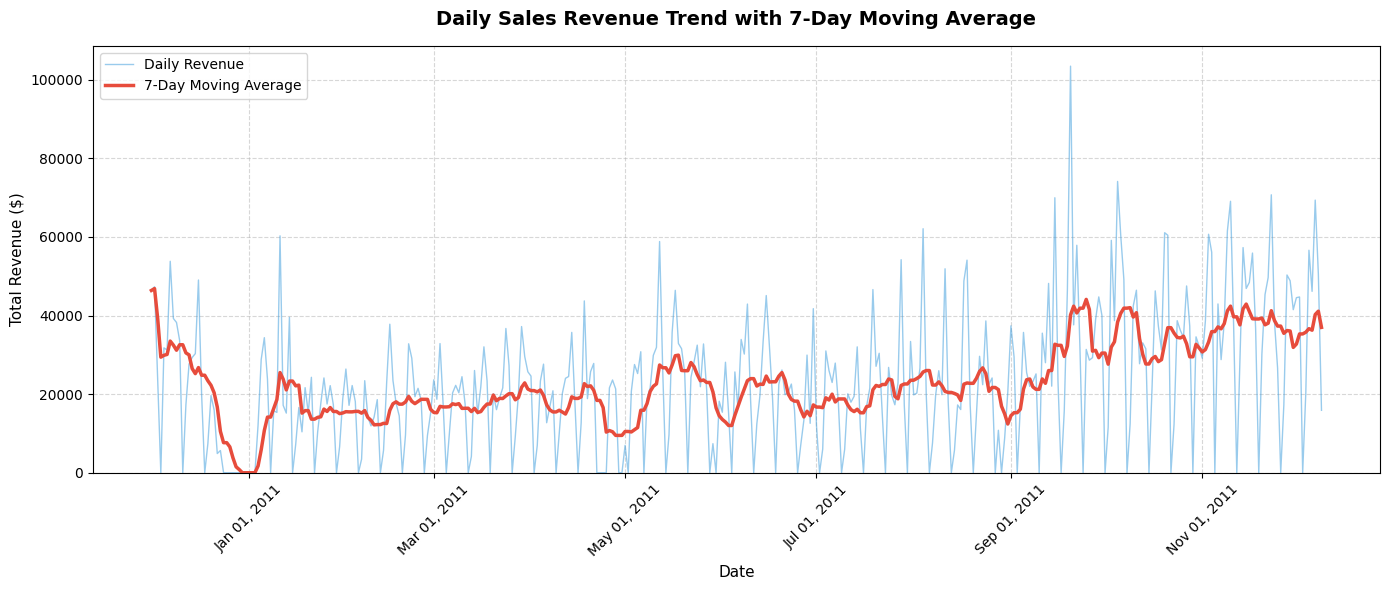

In [60]:
# 1. Ensure clean datetimes and calculate revenue
dfc['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], errors='coerce')
dfc = dfc.dropna(subset=['InvoiceDate'])
dfc['TotalSpent'] = dfc['Quantity'] * dfc['UnitPrice']

# 2. Filter valid sales transactions
df_clean = dfc[(dfc['Quantity'] > 0) & (df['UnitPrice'] > 0)].copy()

# 3. Aggregate by Day ('D')
df_indexed = df_clean.set_index('InvoiceDate')
daily_sales = df_indexed['TotalSpent'].resample('D').sum()

# 4. Calculate a 7-day rolling average to highlight the smooth trend
daily_sales_7d_ma = daily_sales.rolling(window=7, min_periods=1).mean()

# 5. Create Plot with Matplotlib
plt.figure(figsize=(14, 6))

# Plot daily raw data
plt.plot(
    daily_sales.index,
    daily_sales.values,
    color='#3498db',
    linewidth=1,
    alpha=0.5,
    label='Daily Revenue',
)

# Plot 7-day moving average on top
plt.plot(
    daily_sales_7d_ma.index,
    daily_sales_7d_ma.values,
    color='#e74c3c',
    linewidth=2.5,
    label='7-Day Moving Average',
)

# Format X-axis to display clean date ticks automatically
ax = plt.gca()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d, %Y'))
ax.xaxis.set_major_locator(
    mdates.AutoDateLocator()
)  # Automatically picks readable intervals
plt.xticks(rotation=45)

# Labels & Formatting
plt.title(
    'Daily Sales Revenue Trend with 7-Day Moving Average',
    fontsize=14,
    weight='bold',
    pad=15,
)
plt.xlabel('Date', fontsize=11)
plt.ylabel('Total Revenue ($)', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper left', frameon=True)

# Ensure y-axis starts at zero
plt.ylim(bottom=0)

plt.tight_layout()
plt.show()

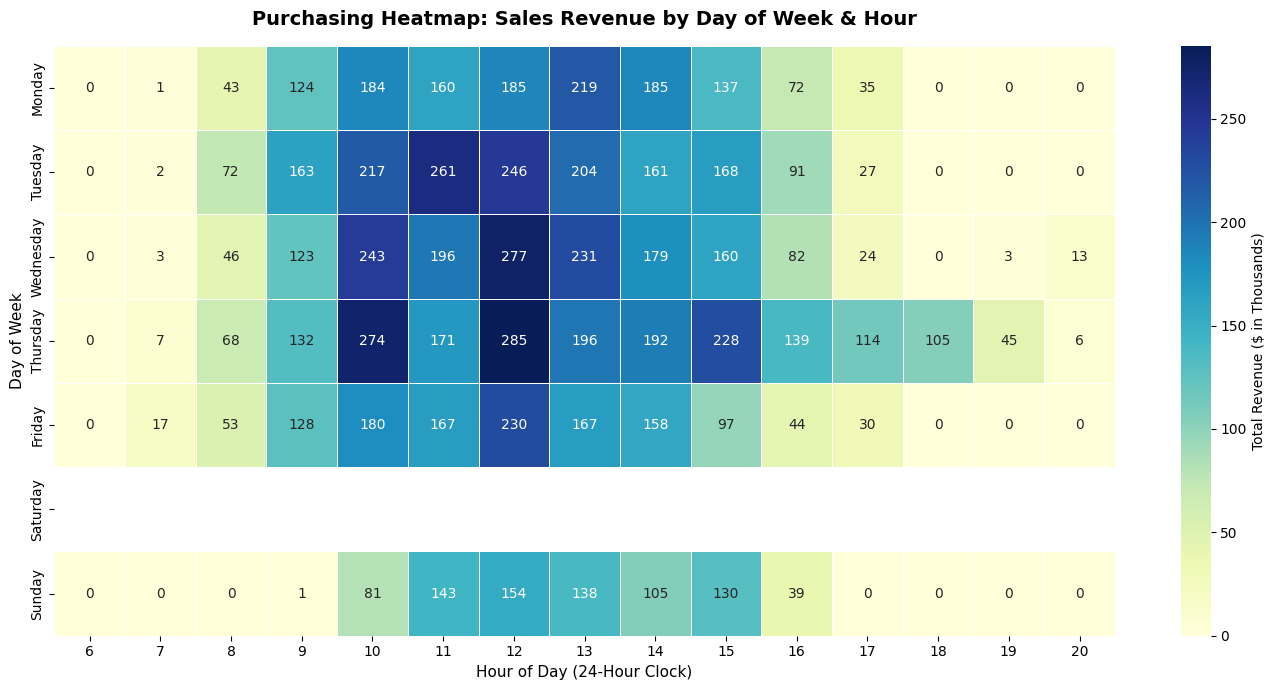

In [61]:
# Now, let's make some heatmaps:

# 1. Ensure InvoiceDate is datetime and filter valid sales
dfc['InvoiceDate'] = pd.to_datetime(
    dfc['InvoiceDate'], format='mixed', errors='coerce'
)
df_clean = dfc[(dfc['Quantity'] > 0) & (dfc['UnitPrice'] > 0)].copy()

# 2. Extract Hour and Day of Week from InvoiceDate
df_clean['Hour'] = df_clean['InvoiceDate'].dt.hour
df_clean['DayOfWeek'] = df_clean['InvoiceDate'].dt.day_name()

# 3. Create Total Spent (Revenue) per transaction
df_clean['TotalSpent'] = df_clean['Quantity'] * df_clean['UnitPrice']

# 4. Pivot data into a Day x Hour grid (calculating total revenue or order count)
# Grouping by TotalSpent sum (you can change 'sum' to 'count' for transaction volume)
heatmap_data = df_clean.pivot_table(
    index='DayOfWeek', columns='Hour', values='TotalSpent', aggfunc='sum'
).fillna(0)

# Reorder days logically (Monday to Sunday)
days_order = [
    'Monday',
    'Tuesday',
    'Wednesday',
    'Thursday',
    'Friday',
    'Saturday',
    'Sunday',
]
heatmap_data = heatmap_data.reindex(days_order)

# 5. Plot the Heatmap
plt.figure(figsize=(14, 7))

sns.heatmap(
    heatmap_data / 1000,  # Convert values to Thousands ($k) for cleaner labels
    cmap='YlGnBu',  # Yellow to Green-Blue gradient (darker = higher sales)
    annot=True,  # Display dollar values inside cells
    fmt='.0f',  # Round numbers to nearest whole $k
    cbar_kws={'label': 'Total Revenue ($ in Thousands)'},
    linewidths=0.5,
    linecolor='white',
)

# Formatting
plt.title(
    'Purchasing Heatmap: Sales Revenue by Day of Week & Hour',
    fontsize=14,
    weight='bold',
    pad=15,
)
plt.xlabel('Hour of Day (24-Hour Clock)', fontsize=11)
plt.ylabel('Day of Week', fontsize=11)

plt.tight_layout()
plt.show()

In [62]:
# From the heatmap above, we can see high sales moments of a week.
# Best time of sales is Thursday at 10am, then Tuesday at 4pm, and then Wednesday at 12noon.

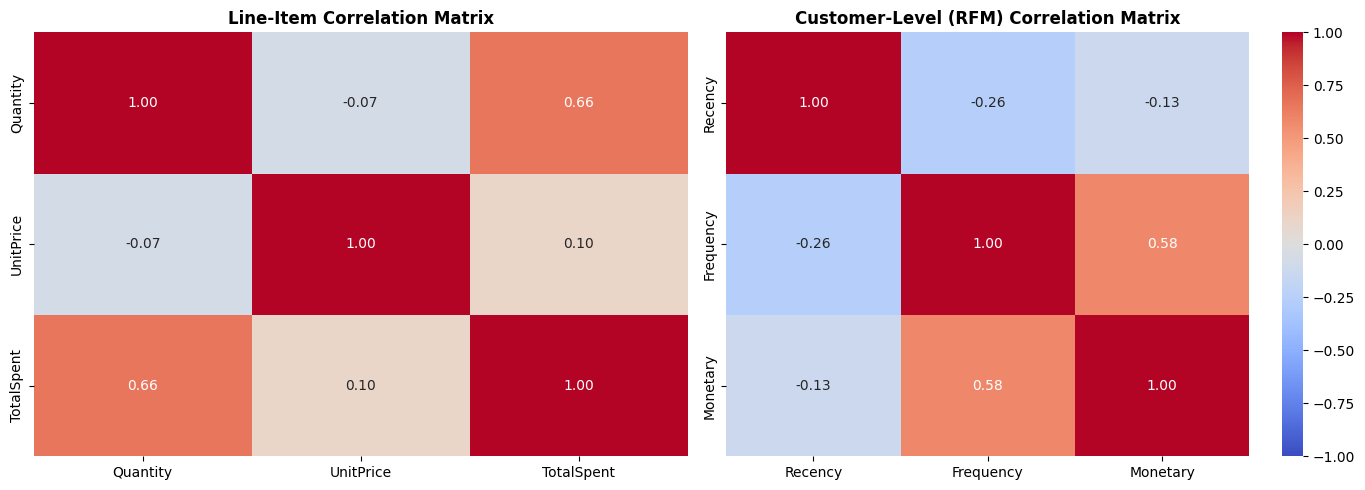

In [63]:
# Now I want to investigate correlations. I think it is most meaningful to investigate correlation for UnitPrice vs Quantity, and Revenue vs Quantity.

# 1. Feature Engineering
dfc['TotalSpent'] = dfc['Quantity'] * dfc['UnitPrice']
df_clean = df[(dfc['Quantity'] > 0) & (dfc['UnitPrice'] > 0)].copy()

# --- MATRIX 1: Line-Item Level Correlations ---
line_item_corr = df_clean[['Quantity', 'UnitPrice', 'TotalSpent']].corr()

# --- MATRIX 2: Customer Aggregated Correlations (RFM Level) ---
# Calculate Recency reference date (max date + 1 day)
max_date = df_clean['InvoiceDate'].max()

customer_df = (
    df_clean.groupby('CustomerID')
    .agg(
        Recency=('InvoiceDate', lambda x: (max_date - x.max()).days),
        Frequency=('InvoiceNo', 'nunique'),
        Monetary=('TotalSpent', 'sum'),
    )
    .reset_index()
)

customer_corr = customer_df[['Recency', 'Frequency', 'Monetary']].corr()

# --- Plotting Side-by-Side Correlation Heatmaps ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Line Item Correlations
sns.heatmap(
    line_item_corr,
    annot=True,
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    fmt='.2f',
    ax=axes[0],
    cbar=False,
)
axes[0].set_title('Line-Item Correlation Matrix', fontsize=12, weight='bold')

# Plot 2: Customer-Level RFM Correlations
sns.heatmap(
    customer_corr,
    annot=True,
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    fmt='.2f',
    ax=axes[1],
)
axes[1].set_title(
    'Customer-Level (RFM) Correlation Matrix', fontsize=12, weight='bold'
)

plt.tight_layout()
plt.show()

In [64]:
# As it can be seen from the above heatmap, the only meaningful correlation is between Quantity and Total-Spent which is +0.66.

In [65]:
# Now it is time to make a hypothesis.

# Context: We observed that some customers make frequent repeat orders while others purchase only once.
# Does higher purchase frequency actually lead to higher overall lifetime revenue, or do repeat buyers just place smaller, split orders?

# Null Hypothesis (H0): There is no correlation between a customer's purchase frequency (number of unique invoices) and their total monetary spend (r = 0).
# Alternative Hypothesis (HA): There is a positive correlation between purchase frequency and total monetary spend (r > 0).



In [66]:
# step 1: Formal Hypothesis StatementNull Hypothesis (H0): There is no correlation between purchase frequency and total monetary spend.
# Alternative Hypothesis (HA): There is a positive correlation between purchase frequency and total monetary spend.
# Significance Level alpha = 0.05 (95% confidence level).

           STATISTICAL HYPOTHESIS TEST RESULTS    
Sample Size (Unique Customers): 4,336
Pearson Correlation (r):       0.5841  (p-value: 0.0000e+00)
Spearman Rank Correlation (r):  0.8074  (p-value: 0.0000e+00)
VERDICT: REJECT THE NULL HYPOTHESIS (H0).
Conclusion: Statistically significant positive correlation exists between Frequency and Monetary spend.


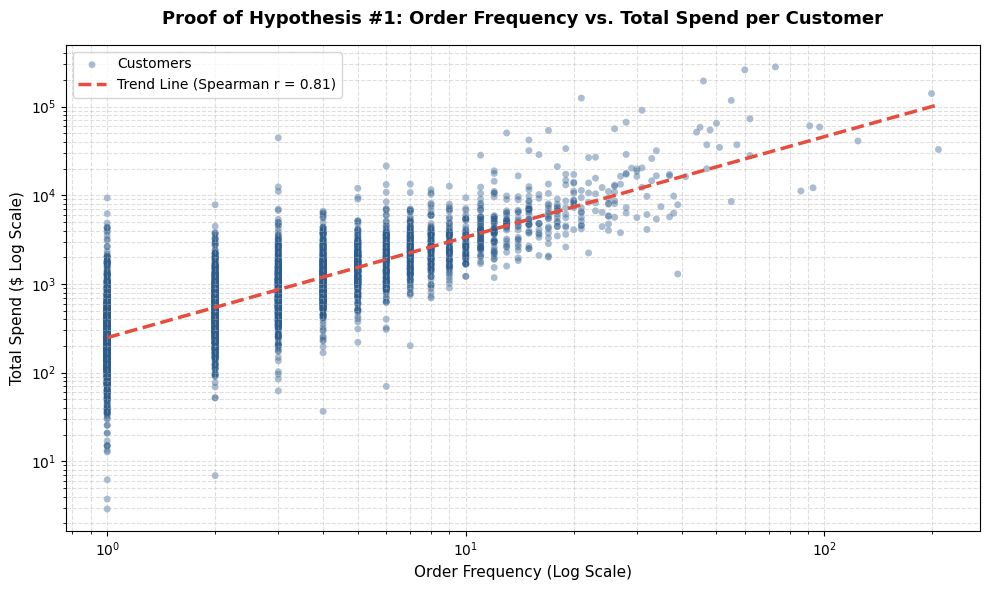

In [67]:
# 1. Clean data & create TotalSpent column
dfc['InvoiceDate'] = pd.to_datetime(
    dfc['InvoiceDate'], format='mixed', errors='coerce'
)
dfc['TotalSpent'] = dfc['Quantity'] * dfc['UnitPrice']

# Filter valid transactions and drop missing CustomerIDs
df_clean = dfc[
    (df['Quantity'] > 0) & (df['UnitPrice'] > 0) & (df['CustomerID'].notna())
].copy()

# 2. Aggregate metrics per customer
customer_rfm = (
    df_clean.groupby('CustomerID')
    .agg(
        Frequency=('InvoiceNo', 'nunique'),
        Monetary=('TotalSpent', 'sum'),
    )
    .reset_index()
)

# 3. Calculate Correlation Coefficients and P-Values
pearson_r, pearson_p = stats.pearsonr(
    customer_rfm['Frequency'], customer_rfm['Monetary']
)
spearman_r, spearman_p = stats.spearmanr(
    customer_rfm['Frequency'], customer_rfm['Monetary']
)

# 4. Print Formal Statistical Output

print('           STATISTICAL HYPOTHESIS TEST RESULTS    ')

print(f'Sample Size (Unique Customers): {len(customer_rfm):,}')
print(
    f'Pearson Correlation (r):       {pearson_r:.4f}  (p-value: {pearson_p:.4e})'
)
print(
    f'Spearman Rank Correlation (r):  {spearman_r:.4f}  (p-value: {spearman_p:.4e})'
)


alpha = 0.05
if spearman_p < alpha:
    print('VERDICT: REJECT THE NULL HYPOTHESIS (H0).')
    print(
        'Conclusion: Statistically significant positive correlation exists between Frequency and Monetary spend.'
    )
else:
    print('VERDICT: FAIL TO REJECT THE NULL HYPOTHESIS (H0).')


# 5. Plot Log-Log Scatter Plot with Trend Line (to handle skewness visually)
plt.figure(figsize=(10, 6))

plt.scatter(
    customer_rfm['Frequency'],
    customer_rfm['Monetary'],
    alpha=0.4,
    color='#2b5c8f',
    edgecolors='none',
    s=25,
    label='Customers',
)

# Log-scale transformation for display clarity
plt.xscale('log')
plt.yscale('log')

# Calculate linear regression line on log values for visualization
log_freq = np.log10(customer_rfm['Frequency'])
log_monetary = np.log10(customer_rfm['Monetary'])
slope, intercept = np.polyfit(log_freq, log_monetary, 1)

x_vals = np.linspace(log_freq.min(), log_freq.max(), 100)
plt.plot(
    10**x_vals,
    10 ** (slope * x_vals + intercept),
    color='#e74c3c',
    linewidth=2.5,
    linestyle='--',
    label=f'Trend Line (Spearman r = {spearman_r:.2f})',
)

plt.title(
    'Proof of Hypothesis #1: Order Frequency vs. Total Spend per Customer',
    fontsize=13,
    weight='bold',
    pad=15,
)
plt.xlabel('Order Frequency (Log Scale)', fontsize=11)
plt.ylabel('Total Spend ($ Log Scale)', fontsize=11)
plt.grid(True, which='both', linestyle='--', alpha=0.4)
plt.legend(loc='upper left', frameon=True)

plt.tight_layout()
plt.show()

In [68]:
# End of Exploratory Data Analysis section.
# In the next section, we will work on 'Feauture Engineering'.

In [69]:
# DSM Step 4: <Feature Engineering>

In [70]:
# For an online retail dataset, the goal during feature engineering is to translate raw transactions into user-level RFM metrics, product-level attributes, and time-series signals.

# We apply two levels of feature engineering:

# 1. Customer-Level Aggregations (RFM)
# 2. Temporal & Behavioral Features

In [71]:
# 1. Customer-Level Aggregations (RFM)

# Aggregate by Customer ID to build customer profiles for segmentation, churn prediction, or lifetime value models.
# Recency: Days since last purchase relative to the dataset snapshot date.
# Frequency: Count of unique Invoice Number items.
# Monetary Value: Calculate total spend per transaction (Quantity \times Unit Price), then sum or average per customer.
# Returns/Cancellations: Count of negative Quantity records, return frequency, and return value ratio.
# Purchase Diversity: Count of unique Stock Code items or categories purchased.
# Inter-purchase Interval: Average, standard deviation, or median days between consecutive orders.


# 2. Temporal & Behavioral Features

# Extract seasonality and behavioral rhythms from Invoice Date.
# Time-of-Day / Day-of-Week: Distribution of orders placed across hours (morning vs. night) or days (weekday vs. weekend).
# Cyclical Transforms: Encode hour (0 to 23) or month (1 to 12) using sine/cosine transformations to preserve continuity.
# Tenure: Days between a customer’s first purchase and their latest purchase.

In [72]:
# Loading the csv file and check data types
# I call the result dataframe as dff;

dff = pd.read_csv('/content/cleansed_data.csv')

In [73]:
dff.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [74]:
dff.dtypes

,0
InvoiceNo,int64
StockCode,object
Description,object
Quantity,int64
InvoiceDate,object
UnitPrice,float64
CustomerID,float64
Country,object


In [75]:
# Let's convert InvoiceDate from object to datetime:

dff['InvoiceDate'] = pd.to_datetime(dff['InvoiceDate'])
dff.dtypes

,0
InvoiceNo,int64
StockCode,object
Description,object
Quantity,int64
InvoiceDate,datetime64[ns]
UnitPrice,float64
CustomerID,float64
Country,object


In [76]:
# ---------------------------------------------------------
# 0. Initial Data Prep
# ---------------------------------------------------------
dff["InvoiceDate"] = pd.to_datetime(dff["InvoiceDate"])
dff["Total Line Value"] = dff["Quantity"] * dff["UnitPrice"]

# Reference date for Recency (1 day after the latest transaction)
snapshot_date = dff["InvoiceDate"].max() + pd.Timedelta(days=1)


# ---------------------------------------------------------
# Section 3: Invoice-Level Aggregations (Aggregated to Customer)
# ---------------------------------------------------------
# First, calculate per-invoice metrics
invoice_summary = (
    dff.groupby(["CustomerID", "InvoiceNo"])
    .agg(
        Invoice_Total_Items=("Quantity", "sum"),
        Invoice_Total_Spend=("Total Line Value", "sum"),
        Invoice_Distinct_Products=("StockCode", "nunique"),
        Invoice_Avg_Item_Price=("UnitPrice", "mean"),
        Invoice_Price_Std=("UnitPrice", "std"),
    )
    .reset_index()
)

# Second, average invoice-level behaviors per customer
customer_invoice_features = (
    invoice_summary.groupby("CustomerID")
    .agg(
        Avg_Basket_Size=("Invoice_Total_Items", "mean"),
        Avg_Basket_Value=("Invoice_Total_Spend", "mean"),
        Avg_Basket_Product_Diversity=("Invoice_Distinct_Products", "mean"),
        Avg_Basket_Item_Price=("Invoice_Avg_Item_Price", "mean"),
        Avg_Basket_Price_Variance=("Invoice_Price_Std", "mean"),
    )
    .reset_index()
    .fillna(0)  # Handle NaN variance for single-item baskets
)


# ---------------------------------------------------------
# Section 4: Product-Level Attributes (Aggregated to Customer)
# ---------------------------------------------------------
# First, calculate product popularity metrics across the entire dataset
product_popularity = (
    dff.groupby("StockCode")["Quantity"].sum().to_dict()
)
dff["Product_Popularity_Score"] = dff["StockCode"].map(product_popularity)

# Second, aggregate customer product preferences & price tier interactions
customer_product_features = (
    dff.groupby("CustomerID")
    .agg(
        Min_Item_Price_Paid=("UnitPrice", "min"),
        Max_Item_Price_Paid=("UnitPrice", "max"),
        Median_Item_Price_Paid=("UnitPrice", "median"),
        Avg_Product_Popularity=("Product_Popularity_Score", "mean"),
    )
    .reset_index()
)


# ---------------------------------------------------------
# Sections 1 & 2: Base RFM & Temporal Features
# ---------------------------------------------------------
dff["Hour"] = dff["InvoiceDate"].dt.hour
dff["DayOfWeek"] = dff["InvoiceDate"].dt.dayofweek
dff["Hour_Sin"] = np.sin(2 * np.pi * dff["Hour"] / 24)
dff["Hour_Cos"] = np.cos(2 * np.pi * dff["Hour"] / 24)

customer_rfm_temporal = (
    dff.groupby("CustomerID")
    .agg(
        Recency=(
            "InvoiceDate",
            lambda x: (snapshot_date - x.max()).days,
        ),
        Frequency=("InvoiceNo", "nunique"),
        Monetary=("Total Line Value", "sum"),
        Avg_Order_Hour_Sin=("Hour_Sin", "mean"),
        Avg_Order_Hour_Cos=("Hour_Cos", "mean"),
        Weekend_Ratio=("DayOfWeek", lambda x: (x >= 5).mean()),
    )
    .reset_index()
)


# ---------------------------------------------------------
# Consolidated Big Table (ML Feature Matrix)
# ---------------------------------------------------------
final_customer_features = (
    customer_rfm_temporal.merge(
        customer_invoice_features, on="CustomerID", how="left"
    )
    .merge(customer_product_features, on="CustomerID", how="left")
)

# Export the master feature dataset for Machine Learning
final_customer_features.to_csv(
    "final_customer_ml_features.csv", index=False
)

In [77]:
final_customer_features.head()

,CustomerID,Recency,Frequency,Monetary,Avg_Order_Hour_Sin,Avg_Order_Hour_Cos,Weekend_Ratio,Avg_Basket_Size,Avg_Basket_Value,Avg_Basket_Product_Diversity,Avg_Basket_Item_Price,Avg_Basket_Price_Variance,Min_Item_Price_Paid,Max_Item_Price_Paid,Median_Item_Price_Paid,Avg_Product_Popularity
0,12347.0,2,7,4310.00,-0.062551,-0.856654,0.000000,351.142857,615.714286,26.000,2.555643,2.066055,0.25,12.75,2.015,4407.032967
1,12348.0,75,4,1797.24,-0.377329,-0.258843,0.096774,585.250000,449.310000,6.750,8.251495,16.369262,0.29,40.00,0.550,9153.870968
2,12349.0,19,1,1757.55,0.707107,-0.707107,0.000000,631.000000,1757.550000,73.000,8.289041,35.028021,0.42,300.00,2.550,3395.205479
3,12350.0,310,1,334.40,-0.866025,-0.500000,0.000000,197.000000,334.400000,17.000,3.841176,9.334751,0.85,40.00,1.650,3171.470588
4,12352.0,36,8,2506.04,-0.483667,-0.819466,0.000000,67.000000,313.255000,10.375,40.790615,19.818431,0.65,376.50,4.250,3501.000000


In [78]:
final_customer_features.shape

(4336, 16)

In [79]:
# As it can be seen, the newly made dataframe has 972 rows and 16 columns.
# This is a totally new table and we will be working with this dataframe for machine learning process.

In [80]:
# Feature Engineering is done, and the above dataframe is our final table for machine learning training.
# Next step is finding a suitable machine learning model.

In [81]:
# DSM Step 5: <Modeling>

In [82]:
# Now it is time to introduce a machine learning model.
# For this type of work, the best model is unsupervised distance-based clustering models.
# First, we go for K-Means Clustering.

In [83]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

In [85]:
# 1. Load Data & Separate Identifier

df = pd.read_csv("final_customer_ml_features.csv")

# Keep Customer ID separate to avoid passing it into the model
customer_ids = df["CustomerID"]
X_raw = df.drop(columns=["CustomerID"])

In [86]:
# 2. Preprocessing: Handle Skewness & Scale Features

# Identify features with heavy right-skew (RFM & Monetary/Basket quantities)
# (Offsetting values by adding a small constant or clipping to prevent log(0))
skewed_cols = [
    "Recency",
    "Frequency",
    "Monetary",
    "Avg_Basket_Size",
    "Avg_Basket_Value",
    "Avg_Basket_Item_Price",
    "Avg_Basket_Price_Variance",
    "Min_Item_Price_Paid",
    "Max_Item_Price_Paid",
    "Median_Item_Price_Paid",
    "Avg_Product_Popularity",
]

X_prep = X_raw.copy()

# Apply log1p transformation to skewed metrics (log(1 + x) handles 0 values safely)
for col in skewed_cols:
    if col in X_prep.columns:
        # Clip negative monetary values at 0 before taking the log
        X_prep[col] = np.log1p(np.maximum(0, X_prep[col]))

In [87]:
# Scale features so distance-based K-Means treats all variables equally
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_prep)

# Convert back to DataFrame for clean inspection
X_scaled_df = pd.DataFrame(X_scaled, columns=X_raw.columns)

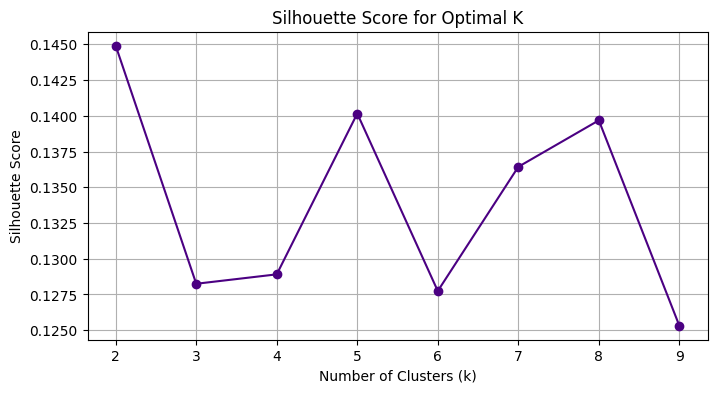

Optimal number of clusters based on Silhouette Score: 2


In [88]:
# 3. Find Optimal K (Silhouette Score Analysis)

silhouette_scores = []
k_range = range(2, 10)

for k in k_range:
    kmeans_test = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans_test.fit_predict(X_scaled_df)
    score = silhouette_score(X_scaled_df, cluster_labels)
    silhouette_scores.append(score)

# Plot Silhouette Scores to evaluate K
plt.figure(figsize=(8, 4))
plt.plot(k_range, silhouette_scores, marker="o", color="indigo")
plt.title("Silhouette Score for Optimal K")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.grid(True)
plt.show()

# Select optimal K automatically based on maximum silhouette score
optimal_k = k_range[np.argmax(silhouette_scores)]
print(f"Optimal number of clusters based on Silhouette Score: {optimal_k}")

In [89]:
# 4. Train Final K-Means Model

kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df["Cluster"] = kmeans_final.fit_predict(X_scaled_df)

In [90]:
# 5. Segment Summary & Profiling

# Display cluster sizes and average core RFM values per segment
cluster_summary = (
    df.groupby("Cluster")
    .agg(
        Customer_Count=("CustomerID", "count"),
        Recency_Mean=("Recency", "mean"),
        Frequency_Mean=("Frequency", "mean"),
        Monetary_Mean=("Monetary", "mean"),
        Avg_Basket_Value=("Avg_Basket_Value", "mean"),
        Weekend_Ratio=("Weekend_Ratio", "mean"),
    )
    .reset_index()
)

print("\n--- Final Customer Segments Profile ---")
print(cluster_summary)


--- Final Customer Segments Profile ---
   Cluster  Customer_Count  Recency_Mean  Frequency_Mean  Monetary_Mean  \
0        0            2262     48.556587        6.557471    3459.415111   
1        1            2074    140.699132        1.771456     355.825912   

   Avg_Basket_Value  Weekend_Ratio  
0        527.400989       0.135605  
1        217.891841       0.128781  


In [91]:
# Export final segmented customers
df.to_csv("customer_segments_final.csv", index=False)

In [92]:
# Let's read the result in pandas format:

# Load your finalized segmented file
df_clustered = pd.read_csv("customer_segments_final.csv")

# Map cluster numbers to meaningful business names (adjust IDs based on your specific cluster_summary output)
segment_mapping = {
    0: "Lost / Hibernating",
    1: "Champions (VIP)",
    2: "At Risk",
    3: "Promising / New",
}

# Add a descriptive column
df_clustered["Segment_Name"] = df_clustered["Cluster"].map(segment_mapping)

# Save the final labeled output
df_clustered.to_csv("customer_segments_labeled.csv", index=False)

In [93]:
df_clustered.head(10)

,CustomerID,Recency,Frequency,Monetary,Avg_Order_Hour_Sin,Avg_Order_Hour_Cos,Weekend_Ratio,Avg_Basket_Size,Avg_Basket_Value,Avg_Basket_Product_Diversity,Avg_Basket_Item_Price,Avg_Basket_Price_Variance,Min_Item_Price_Paid,Max_Item_Price_Paid,Median_Item_Price_Paid,Avg_Product_Popularity,Cluster,Segment_Name
0,12347.0,2,7,4310.00,-0.062551,-0.856654,0.000000,351.142857,615.714286,26.000000,2.555643,2.066055,0.25,12.75,2.015,4407.032967,0,Lost / Hibernating
1,12348.0,75,4,1797.24,-0.377329,-0.258843,0.096774,585.250000,449.310000,6.750000,8.251495,16.369262,0.29,40.00,0.550,9153.870968,0,Lost / Hibernating
2,12349.0,19,1,1757.55,0.707107,-0.707107,0.000000,631.000000,1757.550000,73.000000,8.289041,35.028021,0.42,300.00,2.550,3395.205479,0,Lost / Hibernating
3,12350.0,310,1,334.40,-0.866025,-0.500000,0.000000,197.000000,334.400000,17.000000,3.841176,9.334751,0.85,40.00,1.650,3171.470588,1,Champions (VIP)
4,12352.0,36,8,2506.04,-0.483667,-0.819466,0.000000,67.000000,313.255000,10.375000,40.790615,19.818431,0.65,376.50,4.250,3501.000000,0,Lost / Hibernating
5,12353.0,204,1,89.00,-0.965926,-0.258819,0.000000,20.000000,89.000000,4.000000,6.075000,4.516175,1.45,9.95,6.450,723.250000,1,Champions (VIP)
6,12354.0,232,1,1079.40,-0.258819,-0.965926,0.000000,530.000000,1079.400000,58.000000,4.503793,4.342806,0.42,16.95,2.950,3699.793103,0,Lost / Hibernating
7,12355.0,214,1,459.40,-0.258819,-0.965926,0.000000,240.000000,459.400000,13.000000,4.203846,3.464490,1.25,12.75,2.950,5494.000000,1,Champions (VIP)
8,12356.0,23,3,2811.43,0.460812,-0.804336,0.000000,530.333333,937.143333,19.666667,5.816587,2.812875,0.42,18.00,1.250,4769.372881,0,Lost / Hibernating
9,12357.0,33,1,6207.67,-0.866025,-0.500000,1.000000,2708.000000,6207.670000,131.000000,3.348626,3.548572,0.39,25.00,2.100,2035.267176,0,Lost / Hibernating


In [94]:
df_final = df_clustered.loc[:, ["CustomerID", 'Cluster', "Segment_Name"]]
df_final.sample(10)

,CustomerID,Cluster,Segment_Name
3824,17584.0,0,Lost / Hibernating
2703,16031.0,0,Lost / Hibernating
619,13165.0,0,Lost / Hibernating
1763,14752.0,1,Champions (VIP)
4037,17879.0,1,Champions (VIP)
3545,17193.0,0,Lost / Hibernating
2486,15729.0,1,Champions (VIP)
3456,17062.0,1,Champions (VIP)
4333,18282.0,1,Champions (VIP)
1769,14758.0,1,Champions (VIP)


In [95]:
# Result: K-Means clustering clustered our customers to 6 groups.

In [96]:
# Now, after working with K-Means Clustering, I would like to work with GMM as well.
# GMM stands for Gaussian Mixture Models.
# Some customers may include in two different clusters. GMM gives us a mix of those.
# For example if a customer orders coffee beans, pasta, and a laptop, K-Means only assign one cluster to this customer.
# But GMM assigns a percentage, for example 70% household and 30% Electronics.

In [97]:
from sklearn.mixture import GaussianMixture

# 1. Fit Gaussian Mixture Model with 7 components (matching your K)
gmm = GaussianMixture(n_components=7, random_state=42)
gmm.fit(X_scaled_df)

GaussianMixture(n_components=7, random_state=42)

In [99]:
# 2. Get Hard Cluster Assignments
df["GMM_Cluster"] = gmm.predict(X_scaled_df)

In [100]:
# 3. Get Probabilities (Soft Clustering)
# Returns columns representing the probability of belonging to each of the 7 clusters
probs = gmm.predict_proba(X_scaled_df)
prob_cols = [f"GMM_Prob_Cluster_{i}" for i in range(7)]
probs_df = pd.DataFrame(probs, columns=prob_cols)

In [101]:
# Combine with your main dataset
df_with_gmm = pd.concat([df, probs_df], axis=1)

In [102]:
# Inspect customer #0's cluster probabilities
print(df_with_gmm[["CustomerID", "GMM_Cluster"] + prob_cols].head(10))

   CustomerID  GMM_Cluster  GMM_Prob_Cluster_0  GMM_Prob_Cluster_1  \
0     12347.0            0        9.995017e-01        0.000000e+00   
1     12348.0            5        0.000000e+00        0.000000e+00   
2     12349.0            6       1.661157e-133        1.495207e-15   
3     12350.0            6       3.465371e-129        4.673870e-12   
4     12352.0            5        1.485754e-31        0.000000e+00   
5     12353.0            4       3.146982e-130        1.573518e-15   
6     12354.0            6       2.586693e-132        1.476716e-11   
7     12355.0            6       1.432058e-131        8.211576e-11   
8     12356.0            5        3.006491e-02        0.000000e+00   
9     12357.0            1        0.000000e+00        1.000000e+00   

   GMM_Prob_Cluster_2  GMM_Prob_Cluster_3  GMM_Prob_Cluster_4  \
0        7.487783e-06        4.907819e-04       3.538841e-119   
1        2.160944e-48        5.085567e-30        0.000000e+00   
2        0.000000e+00       1.7680

In [103]:
# For each customer_ID we can see group of probabilities.

In [104]:
# At this step, We are done with preprocessign and modeling.
# I used K-Means Clustering and GMM Clustering.
# Silhoutte score shows the optimal number of clusters for K-Means cliustering, which was 7.
# Unlike K-Means, GMM does not have hard clustering. GMM assigns a set of probabilities to each customer.

In [105]:
# DSM Step 6: <Data Storytelling>

# This step is delivered by Power Point slide deck and is available in capstone-3 repo at my GitHub.